In [ ]:
# ============================================
# 0. Imports & plotting style
# ============================================

# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.api import VAR

# plotting style
plt.style.use("seaborn-v0_8")
pd.options.display.float_format = "{:,.4f}".format

# ============================================
# 1. Helper functions
# ============================================

# annualize monthly data
def annualize_from_monthly(df, date_col, value_cols, how="mean"):
    """
    Convert monthly DataFrame -> annual:
    how = 'mean' or 'max'
    Returns DataFrame with ['Year'] + aggregated columns.
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df["Year"] = df[date_col].dt.year

    if how == "mean":
        agg = df.groupby("Year")[value_cols].mean().reset_index()
    elif how == "max":
        agg = df.groupby("Year")[value_cols].max().reset_index()
    else:
        raise ValueError("how must be 'mean' or 'max'")
    return agg

# load FRED series from CSV
def load_fred_series(path, series_name):
    """
    Robust loader for FRED CSVs stored in Data/.
    Tries to find a date column (DATE or observation_date)
    and the series column by case-insensitive matching.
    """
    df = pd.read_csv(path)

    # 1) find date column
    date_candidates = [
        c for c in df.columns
        if c.lower() in ("date", "observation_date")
    ]
    if not date_candidates:
        raise KeyError(f"No date column found in {path}")
    date_col = date_candidates[0]
    df.rename(columns={date_col: "Date"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"])

    # 2) find series column (case-insensitive)
    if series_name not in df.columns:
        matches = [c for c in df.columns if c.lower() == series_name.lower()]
        if matches:
            df.rename(columns={matches[0]: series_name}, inplace=True)
        else:
            raise KeyError(f"{series_name} column not found in {path}")

    return df

# plot scatter with OLS regression line
def scatter_with_reg(x, y, x_label, y_label, title):
    """
    Simple scatter + OLS regression line with slope / p-value in the title.
    """
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = model.predict(sm.add_constant(x_line))

    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, alpha=0.7)
    plt.plot(x_line, y_line, lw=2)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(
        f"{title}\nSlope={model.params[1]:.3f}, p={model.pvalues[1]:.3f}"
    )
    plt.tight_layout()
    plt.show()
    return model

# plot time-series with event lines
def plot_with_events(x, y, label, ylabel, title, event_years=None):
    """
    Plot a time-series and (optionally) vertical lines for disruption years.
    event_years: dict like {year_int: "Label"} or None
    """
    plt.figure(figsize=(10, 5))
    plt.plot(x, y, label=label)
    plt.ylabel(ylabel)
    plt.xlabel("Year")

    if event_years:
        y_top = plt.ylim()[1]
        for yr, txt in event_years.items():
            plt.axvline(yr, color="red", linestyle="--", alpha=0.5)
            plt.text(
                yr + 0.05,
                y_top,
                txt,
                rotation=90,
                va="top",
                ha="left",
                fontsize=8,
                color="red",
            )

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Event years and labels
EVENT_YEARS = {
    2008: "GFC",
    2011: "Japan EQ / Thai floods",
    2015: "US port strike",
    2020: "COVID shock",
    2021: "Post-COVID congestion / Ever Given",
    2022: "Ukraine war",
}

FOCUS_EVENTS = [2008, 2011, 2020]


In [ ]:

# ============================================
# 2. Load supply chain stress indices
# ============================================

# GSCPI (NY Fed)
gscpi = pd.read_excel("Data/gscpi_data.xlsx", sheet_name="Data")
gscpi["Date"] = pd.to_datetime(gscpi["Date"])
gscpi = gscpi.sort_values("Date")
gscpi = gscpi.rename(columns={"GSCPI": "GSCPI"})

# GSCSI / World Bank global stress index
wb = pd.read_excel("Data/Stress index tables.xlsx", sheet_name="global")

wb = wb.rename(
    columns={
        "Departure_YearMonth": "Date",
        wb.columns[-1]: "GSCSI",  # last column is the index in your file
    }
)
wb["Date"] = pd.to_datetime(wb["Date"], errors="coerce")
wb = wb.sort_values("Date")

In [ ]:

# ============================================
# 3. Load Swiss Re standard insurance data
# ============================================

sri = pd.read_csv("Data/swissre_insurance.csv")

# Focus on US, non-life business, manufacturing-exposed lines
us_nonlife = sri[
    (sri["Country"] == "US")
    & (sri["Business line"].isin(["STOT", "SMEDEX"]))
].copy()

us_nonlife["Year"] = us_nonlife["Time Period"].astype(int)

# Premium exposure metrics
exposure_mask = us_nonlife["Series.1"] == "Premium volume in USD"
growth_mask = us_nonlife["Series.1"] == "Premium real growth"

# pivot to wide format
exp = us_nonlife[exposure_mask].copy()
gr = us_nonlife[growth_mask].copy()

# wide format
exp_wide = (
    exp.pivot_table(
        index="Year", columns="Business line", values="Observation value"
    ).rename(columns=lambda c: f"Premium_USD_{c}")
)

# premium growth wide format
gr_wide = (
    gr.pivot_table(
        index="Year", columns="Business line", values="Observation value"
    ).rename(columns=lambda c: f"PremiumRealGrowth_{c}")
)

# combine exposure + growth
swissre_annual = pd.concat([exp_wide, gr_wide], axis=1).reset_index()

# loss ratios if loss/claims data exist later
loss_mask = us_nonlife["Series.1"].str.contains("loss", case=False, na=False) | \
            us_nonlife["Series.1"].str.contains("claim", case=False, na=False)

# pivot loss data if available
if loss_mask.sum() > 0:
    losses = us_nonlife[loss_mask].copy()
    loss_wide = (
        losses.pivot_table(
            index="Year",
            columns="Business line",
            values="Observation value",
        ).rename(columns=lambda c: f"Losses_USD_{c}")
    )
    swissre_annual = swissre_annual.merge(loss_wide, on="Year", how="left")

    for line in ["STOT", "SMEDEX"]:
        prem_col = f"Premium_USD_{line}"
        loss_col = f"Losses_USD_{line}"
        if prem_col in swissre_annual.columns and loss_col in swissre_annual.columns:
            swissre_annual[f"LossRatio_{line}"] = (
                swissre_annual[loss_col] / swissre_annual[prem_col]
            )
else:
    print(
        "NOTE: No loss/claims series found in Series.1; "
        "swissre_annual contains premium volume & growth only."
    )

print(swissre_annual.head())


NOTE: No loss/claims series found in Series.1; swissre_annual contains premium volume & growth only.
Business line  Year  Premium_USD_SMEDEX  Premium_USD_STOT  \
0              1991            198.3011          646.2900   
1              1992            210.4126          674.6936   
2              1993            225.7799          722.8595   
3              1994            235.1691          760.9909   
4              1995            248.7727          793.8493   

Business line  PremiumRealGrowth_SMEDEX  PremiumRealGrowth_STOT  
0                                0.0416                 -0.0134  
1                                0.0298                  0.0131  
2                                0.0421                  0.0405  
3                                0.0152                  0.0261  
4                                0.0290                  0.0147  


In [ ]:

# ============================================
# 4. Load FRED macro / manufacturing proxies
# ============================================

# business inventories, durable goods orders, IP manufacturing, PPI
businv = load_fred_series("Data/BUSINV.csv", "BUSINV")
dgorder = load_fred_series("Data/DGORDER.csv", "DGORDER")
ipman = load_fred_series("Data/IPMAN.csv", "IPMAN")
ppi = load_fred_series("Data/PPIACO.csv", "PPIACO")

# annualize monthly to yearly (mean)
businv_ann = annualize_from_monthly(businv, "Date", ["BUSINV"], how="mean")
dgorder_ann = annualize_from_monthly(dgorder, "Date", ["DGORDER"], how="mean")

# IP manufacturing YoY%
ipman["IPMAN_YoY"] = ipman["IPMAN"].pct_change(12) * 100
ipman_ann = annualize_from_monthly(
    ipman, "Date", ["IPMAN", "IPMAN_YoY"], how="mean"
)

# PPI YoY%
ppi["PPI_YoY"] = ppi["PPIACO"].pct_change(12) * 100
ppi_ann = annualize_from_monthly(
    ppi, "Date", ["PPIACO", "PPI_YoY"], how="mean"
)

In [ ]:
# ============================================
# 5. Load MSCI sector indices (Auto & Materials)
# ============================================

# MSCI Auto and Materials indices
msci_auto = pd.read_excel("Data/MSCI_Auto.xls")
msci_mat = pd.read_excel("Data/MSCI_Materials.xls")

# rename columns
msci_auto = msci_auto.rename(
    columns={msci_auto.columns[0]: "Date", msci_auto.columns[1]: "MSCI_Auto"}
)
msci_mat = msci_mat.rename(
    columns={msci_mat.columns[0]: "Date", msci_mat.columns[1]: "MSCI_Materials"}
)

# convert Date to datetime
msci_auto["Date"] = pd.to_datetime(msci_auto["Date"])
msci_mat["Date"] = pd.to_datetime(msci_mat["Date"])

# annualize to yearly (mean)
msci_auto_ann = annualize_from_monthly(
    msci_auto, "Date", ["MSCI_Auto"], how="mean"
)
msci_mat_ann = annualize_from_monthly(
    msci_mat, "Date", ["MSCI_Materials"], how="mean"
)

# compute annual returns
msci_auto_ann["MSCI_Auto_Return"] = msci_auto_ann["MSCI_Auto"].pct_change()
msci_mat_ann["MSCI_Materials_Return"] = msci_mat_ann["MSCI_Materials"].pct_change()


In [ ]:
# ============================================
# 6. Annualize stress indices & merge everything
# ============================================

# annualize stress indices
gscpi_ann = annualize_from_monthly(gscpi, "Date", ["GSCPI"], how="mean")
gscpi_ann_max = annualize_from_monthly(gscpi, "Date", ["GSCPI"], how="max")
gscpi_ann_max = gscpi_ann_max.rename(columns={"GSCPI": "GSCPI_max"})
gscpi_ann = gscpi_ann.merge(gscpi_ann_max, on="Year", how="left")

gscsi_ann = annualize_from_monthly(wb, "Date", ["GSCSI"], how="mean")
gscsi_ann_max = annualize_from_monthly(wb, "Date", ["GSCSI"], how="max")
gscsi_ann_max = gscsi_ann_max.rename(columns={"GSCSI": "GSCSI_max"})
gscsi_ann = gscsi_ann.merge(gscsi_ann_max, on="Year", how="left")

# Start master DataFrame with stress indices
df = gscpi_ann.merge(gscsi_ann, on="Year", how="inner")

# Merge Swiss Re insurance metrics
df = df.merge(swissre_annual, on="Year", how="inner")

# Merge FRED macro variables
for macro_df in [businv_ann, dgorder_ann, ipman_ann, ppi_ann]:
    df = df.merge(macro_df, on="Year", how="left")

# Merge MSCI sectors
for eq_df in [msci_auto_ann, msci_mat_ann]:
    df = df.merge(eq_df, on="Year", how="left")

# Restrict to 2000+ and drop very recent partial years if needed
df = df[df["Year"] >= 2000].copy()

# Lag stress indices so that stress in year t affects insurance in t or t+1
df["GSCPI_lag1"] = df["GSCPI"].shift(1)
df["GSCSI_lag1"] = df["GSCSI"].shift(1)

# Final clean-up: drop rows with any missing values
df_model = df.dropna().reset_index(drop=True)
print(df_model.head())
print(df_model.columns)

   Year   GSCPI  GSCPI_max          GSCSI      GSCSI_max  Premium_USD_SMEDEX  \
0  2017  0.3084     0.8131   257,744.0674   471,772.8776            993.8985   
1  2018  0.4445     0.5902   221,054.7853   308,834.0508          1,051.2650   
2  2019 -0.0394     0.5134   293,525.5654   419,825.0926          1,113.1153   
3  2020  1.6567     3.3597   614,624.5983   804,725.1310          1,200.8624   
4  2021  3.0839     4.4628 1,285,982.8979 1,795,985.5425          1,290.6321   

   Premium_USD_STOT  PremiumRealGrowth_SMEDEX  PremiumRealGrowth_STOT  \
0        2,181.9131                    0.0329                  0.0160   
1        2,308.8598                    0.0325                  0.0330   
2        2,424.7901                    0.0400                  0.0315   
3        2,530.0488                    0.0655                  0.0305   
4        2,739.9351                    0.0266                  0.0345   

          BUSINV  ...    IPMAN  IPMAN_YoY   PPIACO  PPI_YoY  MSCI_Auto  \
0 1,87

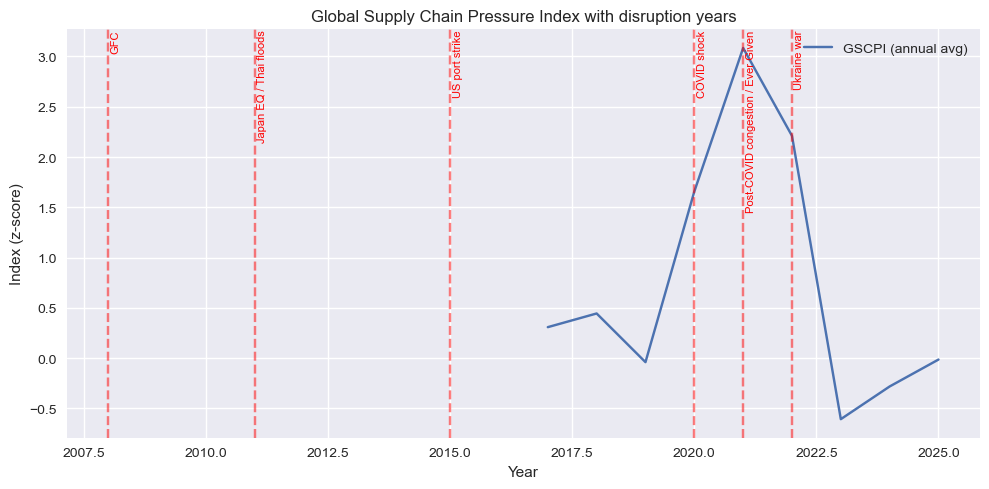

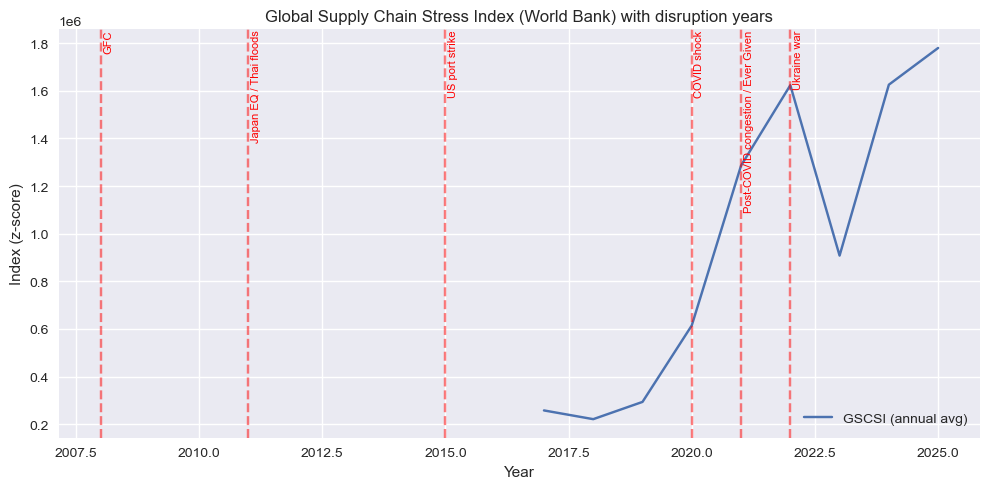

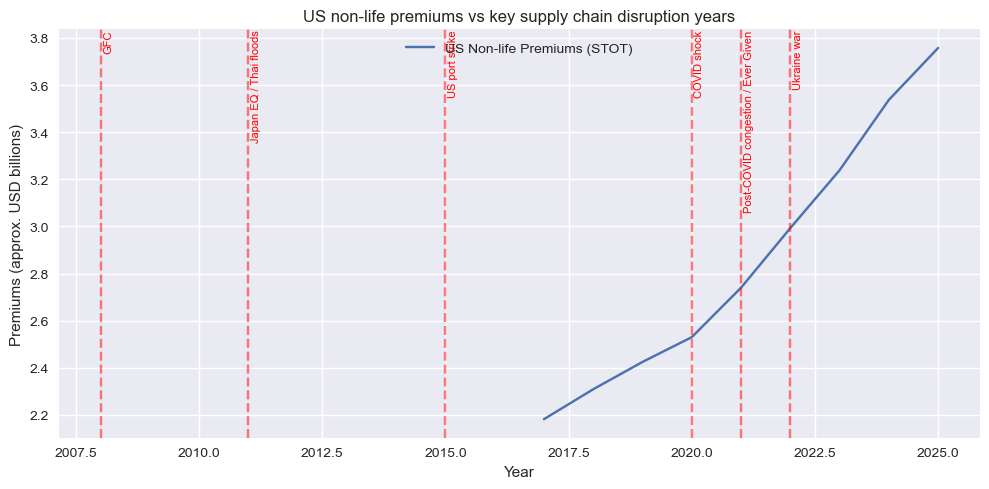

In [ ]:

# ============================================
# 7. Event-annotated charts (descriptive)
# ============================================

# GSCPI with event years
plot_with_events(
    x=df_model["Year"],
    y=df_model["GSCPI"],
    label="GSCPI (annual avg)",
    ylabel="Index (z-score)",
    title="Global Supply Chain Pressure Index with disruption years",
    event_years=EVENT_YEARS,
)

# GSCSI with event years
plot_with_events(
    x=df_model["Year"],
    y=df_model["GSCSI"],
    label="GSCSI (annual avg)",
    ylabel="Index (z-score)",
    title="Global Supply Chain Stress Index (World Bank) with disruption years",
    event_years=EVENT_YEARS,
)

# US non-life premiums with event years
plot_with_events(
    x=df_model["Year"],
    y=df_model["Premium_USD_STOT"] / 1e3,
    label="US Non-life Premiums (STOT)",
    ylabel="Premiums (approx. USD billions)",
    title="US non-life premiums vs key supply chain disruption years",
    event_years=EVENT_YEARS,
)

# Loss ratios with event years
for col in ["LossRatio_STOT", "LossRatio_SMEDEX"]:
    if col in df_model.columns:
        plot_with_events(
            x=df_model["Year"],
            y=df_model[col],
            label=col,
            ylabel="Loss ratio",
            title=f"{col} vs disruption years",
            event_years=EVENT_YEARS,
        )

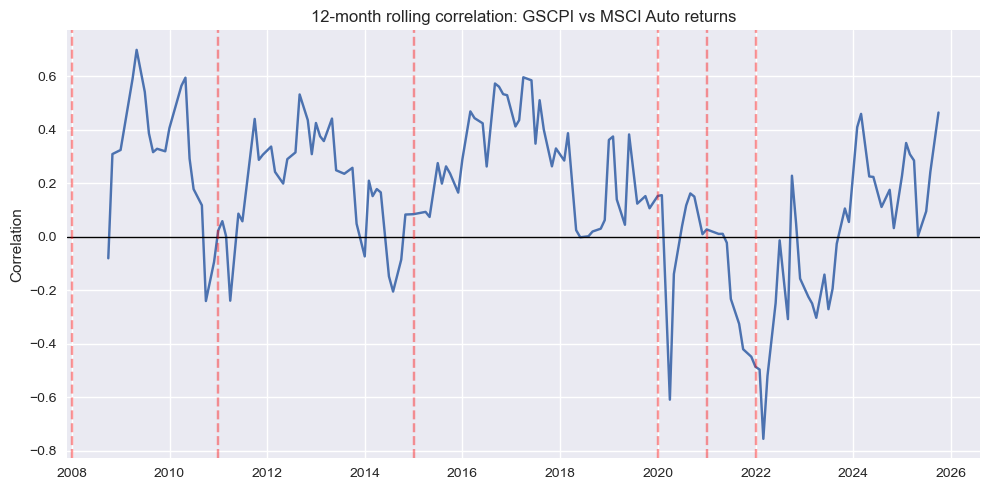

Rolling correlation summary:
  Mean corr (full sample): 0.153
  Min corr: -0.756
  Max corr: 0.698

Around COVID (2019–2021):
  Mean corr: -0.021
  Min corr: -0.61
  Max corr: 0.382


In [ ]:

# ============================================
# 8. Rolling correlations (monthly GSCPI vs MSCI Auto)
# ============================================

# prepare monthly data
monthly = (
    gscpi[["Date", "GSCPI"]]
    .merge(msci_auto[["Date", "MSCI_Auto"]], on="Date", how="inner")
    .sort_values("Date")
    .copy()
)

# compute monthly returns and rolling correlations
monthly["MSCI_Auto_Return"] = monthly["MSCI_Auto"].pct_change() * 100
monthly["GSCPI_3m_roll"] = monthly["GSCPI"].rolling(3).mean()

monthly["Corr_12m"] = monthly["GSCPI"].rolling(12).corr(
    monthly["MSCI_Auto_Return"]
)

# plot rolling correlation
plt.figure(figsize=(10, 5))
plt.plot(monthly["Date"], monthly["Corr_12m"])
plt.axhline(0, color="black", lw=1)
for yr, label in EVENT_YEARS.items():
    plt.axvline(pd.Timestamp(f"{yr}-01-01"), color="red", linestyle="--", alpha=0.4)
plt.title("12-month rolling correlation: GSCPI vs MSCI Auto returns")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

# summarize rolling correlation statistics
corr_window = monthly.dropna(subset=["Corr_12m"])
print("Rolling correlation summary:")
print("  Mean corr (full sample):", round(corr_window["Corr_12m"].mean(), 3))
print("  Min corr:", round(corr_window["Corr_12m"].min(), 3))
print("  Max corr:", round(corr_window["Corr_12m"].max(), 3))

# focus on COVID period
covid_window = corr_window[
    (corr_window["Date"] >= "2019-01-01")
    & (corr_window["Date"] <= "2021-12-31")
]
# summarize COVID-period rolling correlation statistics
print("\nAround COVID (2019–2021):")
print("  Mean corr:", round(covid_window["Corr_12m"].mean(), 3))
print("  Min corr:", round(covid_window["Corr_12m"].min(), 3))
print("  Max corr:", round(covid_window["Corr_12m"].max(), 3))

STOT: baseline mean growth = 0.026
SMEDEX: baseline mean growth = 0.036

Event windows (t-1, t, t+1) around key disruptions:
   EventYear  RelYear  Year  GR_STOT  GR_SMEDEX  Abn_STOT  Abn_SMEDEX
0       2008       -1  2007   0.0256     0.0557   -0.0009      0.0199
1       2008        0  2008  -0.0205     0.0281   -0.0470     -0.0076
2       2008        1  2009  -0.0291     0.0416   -0.0555      0.0059
3       2011       -1  2010  -0.0047     0.0071   -0.0312     -0.0286
4       2011        0  2011   0.0461     0.0576    0.0196      0.0219
5       2011        1  2012   0.0249     0.0242   -0.0016     -0.0115
6       2020       -1  2019   0.0315     0.0400    0.0050      0.0043
7       2020        0  2020   0.0305     0.0655    0.0041      0.0298
8       2020        1  2021   0.0345     0.0266    0.0080     -0.0091


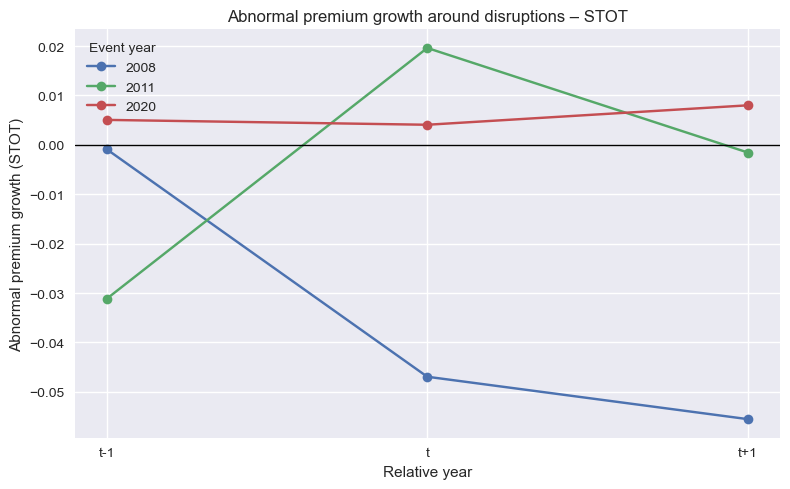

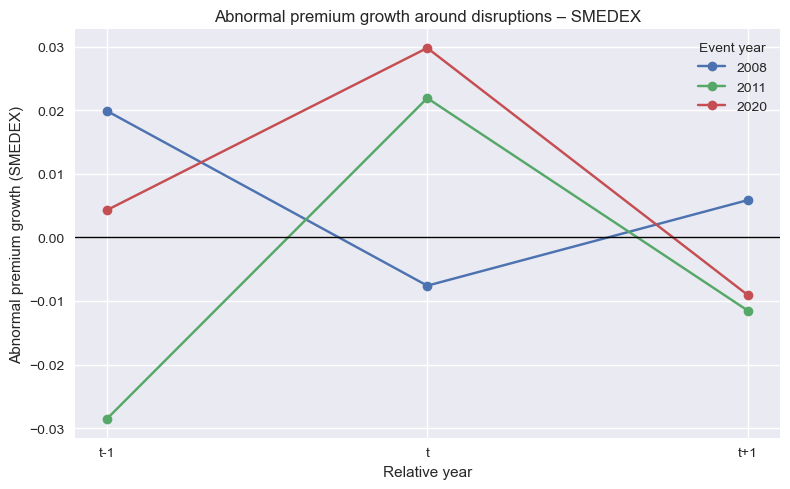

In [ ]:
# ============================================
# 9. Event-style causal analysis (annual data)
# ============================================

# Build a long annual panel for premiums and growth
event_panel = swissre_annual.copy()
event_panel = event_panel[event_panel["Year"] >= 2000].copy()

# Abnormal premium growth: subtract non-event average
for line in ["STOT", "SMEDEX"]:
    gcol = f"PremiumRealGrowth_{line}"
    if gcol not in event_panel.columns:
        continue

    # exclude event years +/- 1 when computing "normal" mean
    exclude_years = set()
    for e in FOCUS_EVENTS:
        exclude_years.update([e - 1, e, e + 1])

    mask_normal = ~event_panel["Year"].isin(exclude_years)
    baseline_mean = event_panel.loc[mask_normal, gcol].mean()

    event_panel[f"AbnormalGrowth_{line}"] = event_panel[gcol] - baseline_mean
    print(f"{line}: baseline mean growth = {baseline_mean:.3f}")

# Extract t-1, t, t+1 windows around key events
rows = []
for e in FOCUS_EVENTS:
    for rel in [-1, 0, 1]:
        year = e + rel
        row = event_panel[event_panel["Year"] == year]
        if row.empty:
            continue
        row = row.iloc[0]
        rows.append(
            {
                "EventYear": e,
                "RelYear": rel,
                "Year": year,
                "GR_STOT": row.get("PremiumRealGrowth_STOT", np.nan),
                "GR_SMEDEX": row.get("PremiumRealGrowth_SMEDEX", np.nan),
                "Abn_STOT": row.get("AbnormalGrowth_STOT", np.nan),
                "Abn_SMEDEX": row.get("AbnormalGrowth_SMEDEX", np.nan),
            }
        )

event_windows = pd.DataFrame(rows)
print("\nEvent windows (t-1, t, t+1) around key disruptions:")
print(event_windows)

# Quick visualization: abnormal growth around events
for line in ["STOT", "SMEDEX"]:
    col = f"Abn_{line}"
    if col not in event_windows.columns:
        continue

    plt.figure(figsize=(8, 5))
    for e in FOCUS_EVENTS:
        sub = event_windows[event_windows["EventYear"] == e]
        if sub.empty:
            continue
        plt.plot(
            sub["RelYear"],
            sub[col],
            marker="o",
            label=f"{e}",
        )
    plt.axhline(0, color="black", lw=1)
    plt.xticks([-1, 0, 1], ["t-1", "t", "t+1"])
    plt.xlabel("Relative year")
    plt.ylabel(f"Abnormal premium growth ({line})")
    plt.title(f"Abnormal premium growth around disruptions – {line}")
    plt.legend(title="Event year")
    plt.tight_layout()
    plt.show()

In [10]:

# ============================================
# 10. Difference-in-differences style comparison
#      (SMEDEX vs STOT around events)
# ============================================
# Treated = SMEDEX (more commercial/industrial),
# Control = STOT (total non-life).

did_rows = []
for e in FOCUS_EVENTS:
    pre_year = e - 1
    post_years = [e, e + 1]

    pre = event_panel[event_panel["Year"] == pre_year]
    post = event_panel[event_panel["Year"].isin(post_years)]

    if pre.empty or post.empty:
        continue

    pre_delta = (
        pre["PremiumRealGrowth_SMEDEX"].iloc[0]
        - pre["PremiumRealGrowth_STOT"].iloc[0]
    )
    post_delta = (
        post["PremiumRealGrowth_SMEDEX"].mean()
        - post["PremiumRealGrowth_STOT"].mean()
    )
    did = post_delta - pre_delta

    did_rows.append(
        {
            "EventYear": e,
            "PreDelta_SMEDEX_minus_STOT": pre_delta,
            "PostDelta_SMEDEX_minus_STOT": post_delta,
            "DiD_Effect": did,
        }
    )

did_table = pd.DataFrame(did_rows)
print("\nSimple DiD-style comparison (SMEDEX vs STOT):")
print(did_table)


Simple DiD-style comparison (SMEDEX vs STOT):
   EventYear  PreDelta_SMEDEX_minus_STOT  PostDelta_SMEDEX_minus_STOT  \
0       2008                      0.0300                       0.0596   
1       2011                      0.0119                       0.0054   
2       2020                      0.0085                       0.0136   

   DiD_Effect  
0      0.0296  
1     -0.0064  
2      0.0051  



VAR data sample (head):
       GSCPI  PremiumRealGrowth_STOT
Year                                
2000 -0.2364                  0.0524
2001 -0.9092                 -0.0179
2002 -0.7477                  0.0981
2003 -0.2556                  0.0390
2004 -0.0484                  0.0207
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 09, Dec, 2025
Time:                     16:06:11
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -6.99240
Nobs:                     25.0000    HQIC:                  -7.20379
Log likelihood:           26.1147    FPE:                0.000687392
AIC:                     -7.28493    Det(Omega_mle):     0.000547985
--------------------------------------------------------------------
Results for equation GSCPI
                               coefficient       std. error           t-stat            prob
-------

/Users/adi/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


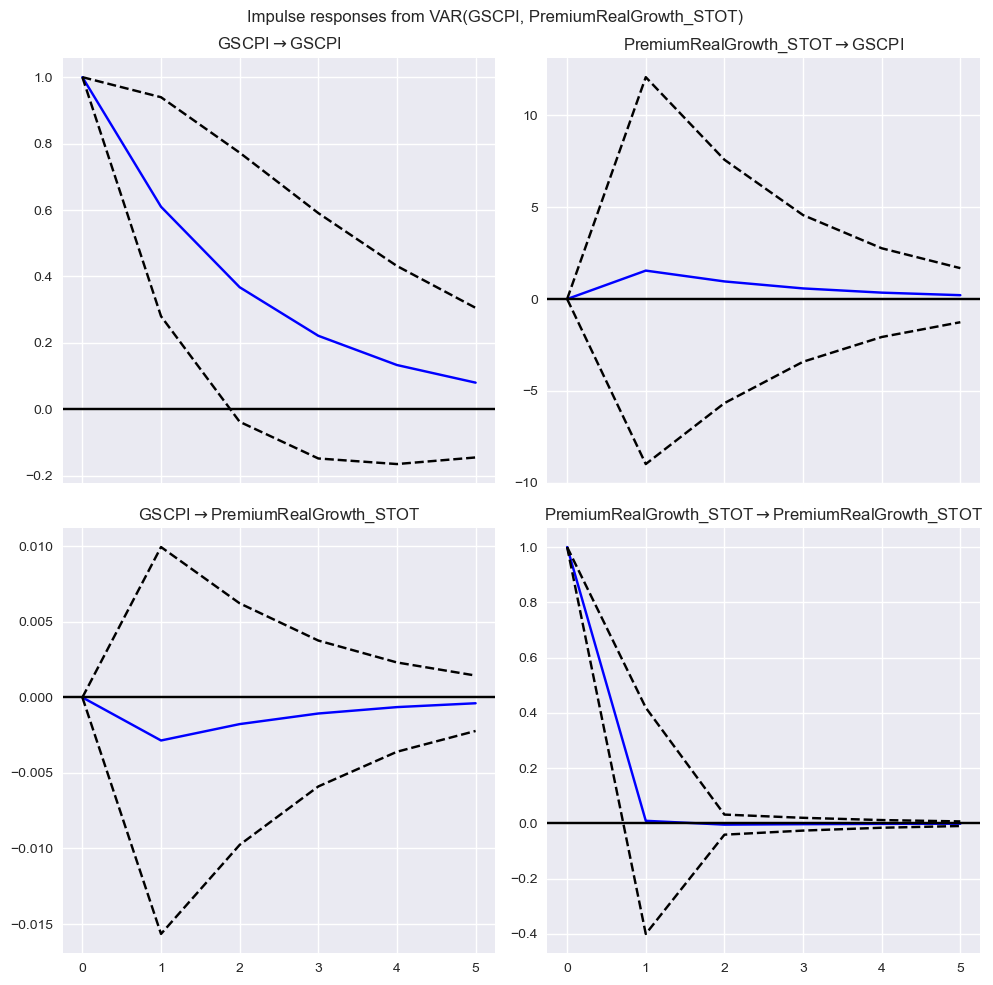


IRF of PremiumRealGrowth_STOT to 1 s.d. GSCPI shock (horizons 0–5):
h=0: 0.0000
h=1: -0.0029
h=2: -0.0018
h=3: -0.0011
h=4: -0.0006
h=5: -0.0004


In [ ]:
# ============================================
# 11. VAR: impulse response of premiums to GSCPI shocks
# ============================================
# Build a longer annual sample (GSCPI + STOT premium growth) for 2000+
var_df = (
    gscpi_ann[["Year", "GSCPI"]]
    .merge(
        swissre_annual[["Year", "PremiumRealGrowth_STOT"]],
        on="Year",
        how="inner",
    )
)
var_df = var_df[var_df["Year"] >= 2000].dropna().reset_index(drop=True)
var_df = var_df.set_index("Year")

print("\nVAR data sample (head):")
print(var_df.head())

# Fit a 1- or 2-lag VAR
model_var = VAR(var_df[["GSCPI", "PremiumRealGrowth_STOT"]])
results_var = model_var.fit(maxlags=2, ic="aic")
print(results_var.summary())

# Impulse response: shock in GSCPI -> response of premium growth
irf = results_var.irf(5)  # 5-year horizon
irf.plot(orth=False)
plt.suptitle("Impulse responses from VAR(GSCPI, PremiumRealGrowth_STOT)")
plt.tight_layout()
plt.show()

# Numeric IRFs for the premium-growth equation
irf_table = irf.irfs[:, 1, 0]  # response of variable 1 (premium growth) to shock in 0 (GSCPI)
print("\nIRF of PremiumRealGrowth_STOT to 1 s.d. GSCPI shock (horizons 0–5):")
for h, val in enumerate(irf_table):
    print(f"h={h}: {val:.4f}")
